# Q-table Diagnostics — Run 35 vs Run 32

This notebook loads the trained predator/prey pair for a chosen run (default 35) and a baseline run (default 32), extracts their Q-tables, and produces diagnostics:
- Argmax-action histogram (preferred action counts per state)
- Q-value heatmaps (states × actions)
- Top state-action table (highest Q entries)

Figures are saved under `src/models/results/` and shown inline. Adjust `RUN_NUM` and `BASE_RUN` at the top and re-run cells.

In [14]:
# Imports and utilities
import pickle, json, math
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists() and (candidate / 'pyproject.toml').exists():
            return candidate
    return start

ROOT = find_repo_root(Path.cwd().resolve())

sns.set(style='whitegrid')
OUT_DIR = ROOT / 'src' / 'models' / 'results'
OUT_DIR.mkdir(parents=True, exist_ok=True)
def find_q(obj):
    # robust recursive extractor for Q-like arrays
    try:
        if isinstance(obj, (list, tuple, np.ndarray)):
            arr = np.array(obj)
            if arr.ndim in (1,2) and arr.size>0:
                return arr
    except Exception:
        pass
    if isinstance(obj, dict):
        vals = list(obj.values())
        # try direct 2D array from mapping
        try:
            arr = np.array(vals)
            if arr.ndim==2:
                return arr
        except Exception:
            pass
        for v in vals:
            q = find_q(v)
            if q is not None:
                return q
    if hasattr(obj, '__dict__'):
        for v in vars(obj).values():
            q = find_q(v)
            if q is not None:
                return q
    if hasattr(obj, '__iter__') and not isinstance(obj, (str, bytes, bytearray)):
        try:
            for v in obj:
                q = find_q(v)
                if q is not None:
                    return q
        except Exception:
            pass
    return None

In [15]:
# Configuration: change these to inspect different runs
RUN_NUM = 35
BASE_RUN = 32

def pred_path(n):
    return ROOT / 'src' / 'models' / f'trained_predator_{n}_protocol1_1v1.pkl'
def prey_path(n):
    return ROOT / 'src' / 'models' /  f'trained_prey_{n}_protocol1_1v1.pkl'
# load function
def load_q_for(role, n):
    p = pred_path(n) if role=='predator' else prey_path(n)
    if not p.exists():
        raise FileNotFoundError(p)
    with open(p,'rb') as f:
        obj = pickle.load(f)
    q = find_q(obj)
    if q is None:
        raise ValueError('Q-table not found in '+str(p))
    q = np.array(q)
    # ensure shape states x actions when possible (heuristic)
    if q.ndim==2 and q.shape[0] < q.shape[1]:
        q = q.T
    return q
# load q-tables for predators baseline and run
q_pred_base = load_q_for('predator', BASE_RUN)
q_pred_run  = load_q_for('predator', RUN_NUM)
print('Loaded predator Q shapes: base=', q_pred_base.shape, 'run=', q_pred_run.shape)

Loaded predator Q shapes: base= (131, 10) run= (131, 10)


In [16]:
# Basic statistics and comparison
def q_stats(q):
    return dict(shape=q.shape, q_min=float(np.nanmin(q)), q_max=float(np.nanmax(q)), q_mean=float(np.nanmean(q)), q_std=float(np.nanstd(q)))
stats_base = q_stats(q_pred_base)
stats_run = q_stats(q_pred_run)
print('Base predator stats:', stats_base)
print('Run predator stats :', stats_run)
# save stats
(OUT_DIR / f'predator_q_stats_{BASE_RUN}.json').write_text(json.dumps(stats_base))
(OUT_DIR / f'predator_q_stats_{RUN_NUM}.json').write_text(json.dumps(stats_run))

Base predator stats: {'shape': (131, 10), 'q_min': -9.999999999999993, 'q_max': 29.834774816228517, 'q_mean': 1.2444422157992203, 'q_std': 4.509857527750283}
Run predator stats : {'shape': (131, 10), 'q_min': -9.999999999999993, 'q_max': 29.844071436436785, 'q_mean': 2.0363297019520927, 'q_std': 5.599080088193971}


136

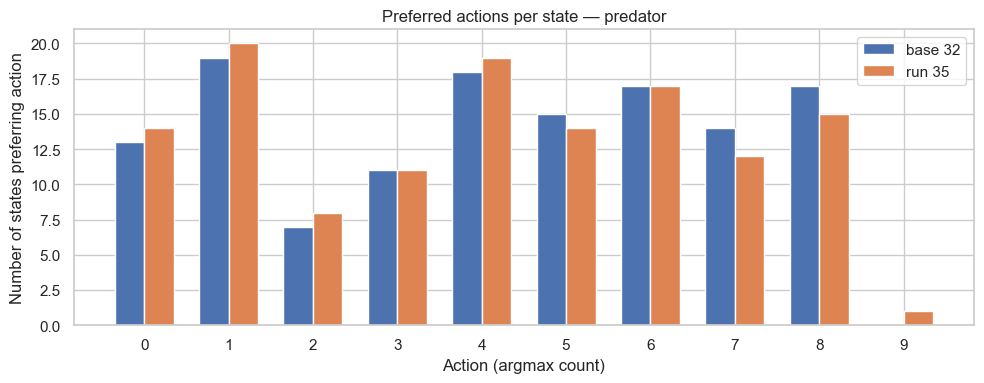

In [17]:
# Argmax-action histogram (preferred action per state)
def argmax_counts(q):
    argmax = np.nanargmax(q, axis=1)
    vals, counts = np.unique(argmax, return_counts=True)
    return dict(zip([int(v) for v in vals], [int(c) for c in counts]))
counts_base = argmax_counts(q_pred_base)
counts_run  = argmax_counts(q_pred_run)
actions = sorted(set(list(counts_base.keys())+list(counts_run.keys())))
base_vals = [counts_base.get(a,0) for a in actions]
run_vals  = [counts_run.get(a,0) for a in actions]
x = np.arange(len(actions))
plt.figure(figsize=(10,4))
width=0.35
plt.bar(x-width/2, base_vals, width, label=f'base {BASE_RUN}')
plt.bar(x+width/2, run_vals, width, label=f'run {RUN_NUM}')
plt.xticks(x, actions)
plt.xlabel('Action (argmax count)')
plt.ylabel('Number of states preferring action')
plt.title('Preferred actions per state — predator')
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / f'predator_argmax_hist_{BASE_RUN}_vs_{RUN_NUM}.png')
plt.show()

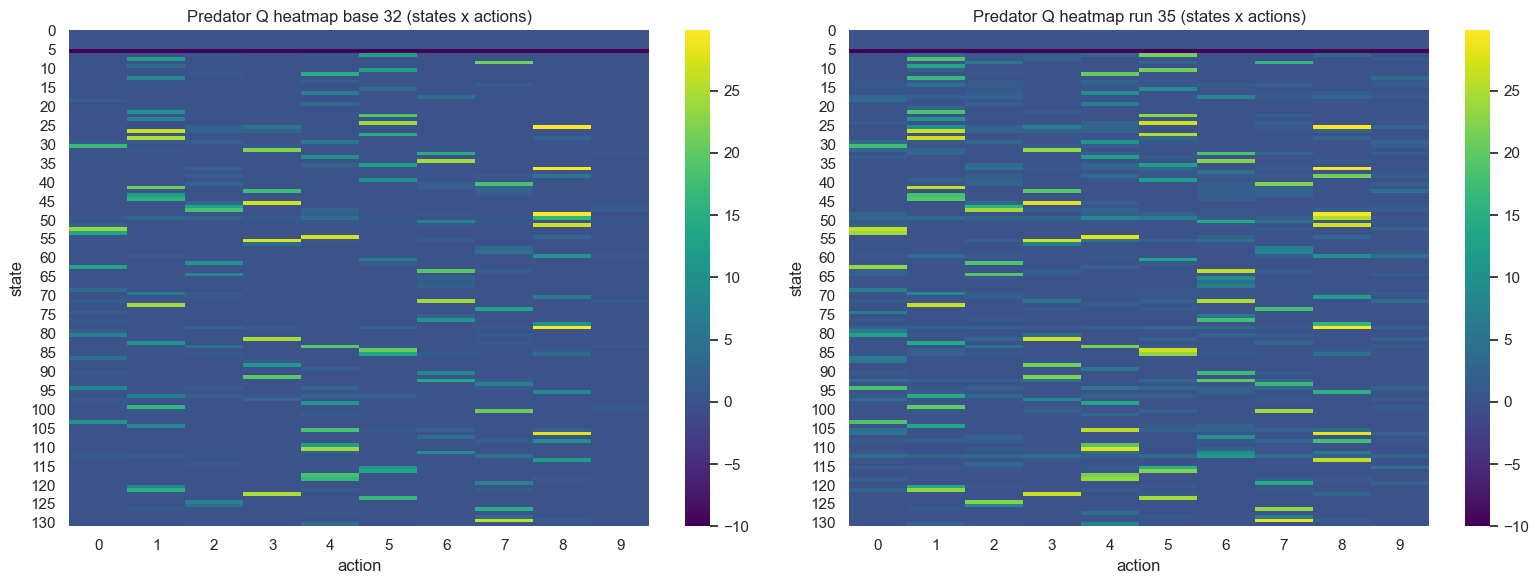

In [18]:
# Q-value heatmaps (states x actions) — use shared color scale for direct comparison
vmin = min(np.nanmin(q_pred_base), np.nanmin(q_pred_run))
vmax = max(np.nanmax(q_pred_base), np.nanmax(q_pred_run))
fig, axes = plt.subplots(1,2, figsize=(16,6))
sns.heatmap(q_pred_base, ax=axes[0], cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title(f'Predator Q heatmap base {BASE_RUN} (states x actions)')
axes[0].set_xlabel('action')
axes[0].set_ylabel('state')
sns.heatmap(q_pred_run, ax=axes[1], cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title(f'Predator Q heatmap run {RUN_NUM} (states x actions)')
axes[1].set_xlabel('action')
axes[1].set_ylabel('state')
plt.tight_layout()
plt.savefig(OUT_DIR / f'predator_q_heatmap_{BASE_RUN}_vs_{RUN_NUM}.png')
plt.show()

In [19]:
# Top state-action pairs (highest Q values) for each model — show top 20 and save to CSV
def top_state_actions(q, topk=20):
    flat_idx = np.argsort(q.flatten())[::-1][:topk]
    rows = []
    for idx in flat_idx:
        s,a = divmod(int(idx), q.shape[1])
        rows.append({'state':int(s),'action':int(a),'value':float(q.flatten()[idx])})
    return pd.DataFrame(rows)
top_base = top_state_actions(q_pred_base, topk=50)
top_run  = top_state_actions(q_pred_run, topk=50)
# save CSVs
top_base.to_csv(OUT_DIR / f'predator_top_actions_{BASE_RUN}.csv', index=False)
top_run.to_csv(OUT_DIR / f'predator_top_actions_{RUN_NUM}.csv', index=False)
# display top 20 for quick inspection
print('Top 20 — base')
display(top_base.head(20))
print('Top 20 — run')
display(top_run.head(20))

Top 20 — base


,state,action,value
0,25,8,29.834775
1,36,8,29.832314
2,78,8,29.831140
3,48,8,29.602423
4,106,8,28.229579
5,55,3,27.612653
6,45,3,27.269774
7,54,4,27.136929
8,51,8,27.015856
9,26,1,26.436456


Top 20 — run


,state,action,value
0,36,8,29.844071
1,48,8,29.825192
2,78,8,29.718859
3,25,8,29.425757
4,129,7,28.361151
5,106,8,28.338409
6,110,4,28.124098
7,54,4,27.994221
8,45,3,27.763491
9,51,8,27.269401


## Next steps
- Run this notebook (or the notebook cells) — figures will be saved to `src/models/results/`.
- If you want, I can run the notebook now and attach the generated PNGs and CSVs.
- You can change `RUN_NUM` to probe other checkpoints.